In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Question 3

## 3.1 GMM class

In [2]:
class GMM:
    """
    Gaussian Mixture Model
    """
    def __init__(self, n_clusters, max_iter=100, tol=1e-4):
        """
        Initialize the GMM with the number of clusters, maximum iterations, and tolerance.
        """
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.means = None
        self.covariances = None
        self.log_likelihoods = []
        
    def _initialize_parameters(self, X):
        """
        Initialize the GMM parameters.
        """
        n_samples, n_features = X.shape
        self.means = X[np.random.choice(n_samples, self.n_clusters, replace=False)]
        # self.covariances = np.array([np.eye(n_features) for _ in range(self.n_clusters)])
        # random covariance matrix
        self.covariances = np.array([np.cov(X, rowvar=False) for _ in range(self.n_clusters)])
        self.weights = np.ones(self.n_clusters) / self.n_clusters
        self.log_likelihoods = []

    def _gaussian_pdf(self, X, mean, covariance):
        """
        Compute the Gaussian probability density function.
        """
        n_features = X.shape[1]
        covariance = covariance + 1e-6 * np.eye(n_features)
        covariance_det = np.linalg.det(covariance)
        if covariance_det <= 0:
            return np.zeros(X.shape[0])
        
        covariance_inv = np.linalg.inv(covariance)
        coeff = 1.0 / np.sqrt((2 * np.pi) ** n_features * covariance_det)
        diff = X - mean
        exponent = -0.5 * np.sum(diff @ covariance_inv * diff, axis=1)
        return coeff * np.exp(exponent)
    
    def _e_step(self, X):
        """
        E-step: Compute responsibilities.
        """
        n_samples = X.shape[0]
        responsibilities = np.zeros((n_samples, self.n_clusters))

        for k in range(self.n_clusters):
            likelihood = self._gaussian_pdf(X, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * likelihood

        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True) + 1e-10
        log_likelihood = np.sum(np.log(responsibilities_sum))

        responsibilities /= responsibilities_sum
        return responsibilities, log_likelihood

    def _m_step(self, X, responsibilities):
        """
        M-step: Update parameters.
        """
        n_samples, n_features = X.shape
        Nk = responsibilities.sum(axis=0)

        self.weights = Nk / n_samples
        self.means = (responsibilities.T @ X) / Nk[:, np.newaxis]
        regulization = 1e-6 * np.eye(n_features)
        for k in range(self.n_clusters):
            diff = X - self.means[k]
            weighted_sum = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff
            self.covariances[k] = weighted_sum / Nk[k] + regulization

    def fit(self, X, n_init=5):
        """
        Fit the GMM model to the data.
        """
        best_log_likelihood = -np.inf
        best_params = None

        for init_num in range(n_init):
            self._initialize_parameters(X)
            log_likelihood_old = -1e10
            self.log_likelihoods = []

            for i in range(self.max_iter):
                responsibilities, new_log_likelihood = self._e_step(X)
                self._m_step(X, responsibilities)
                self.log_likelihoods.append(new_log_likelihood)

                if abs(new_log_likelihood - log_likelihood_old) < self.tol:
                    break
                log_likelihood_old = new_log_likelihood

            # Keep the best parameters based on final log-likelihood
            if new_log_likelihood > best_log_likelihood:
                best_log_likelihood = new_log_likelihood
                best_params = {
                    'weights': self.weights.copy(),
                    'means': self.means.copy(),
                    'covariances': self.covariances.copy(),
                    'log_likelihoods': self.log_likelihoods.copy()
                }

        # Set the model to the best parameters
        self.weights = best_params['weights']
        self.means = best_params['means']
        self.covariances = best_params['covariances']
        self.log_likelihoods = best_params['log_likelihoods']

        print(f'Fitted with best log-likelihood: {best_log_likelihood}')


    def getMembership(self, data):
        """
        Get the membership probabilities for each cluster.
        """
        responsibilities = np.zeros((data.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            pdf_vals = self._gaussian_pdf(data, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * pdf_vals

        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True)
        # Normalize to get probabilities
        memberships = responsibilities / (responsibilities_sum + 1e-9)
        return memberships

    def getLikelihood(self, data):
        """
        Get the log-likelihood of the data under the current model.
        """
        responsibilities = np.zeros((data.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            pdf_vals = self._gaussian_pdf(data, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * pdf_vals
            
        # The likelihood for each point is the sum of weighted PDFs
        likelihood_per_sample = responsibilities.sum(axis=1)
        
        # The total log-likelihood is the sum of the logs of these likelihoods
        total_log_likelihood = np.sum(np.log(likelihood_per_sample + 1e-9))
        return total_log_likelihood

    def drawLikelihood(self):
        """
        Plot the log-likelihood over iterations.
        """
        plt.figure(figsize=(8, 6))
        plt.plot(range(1, len(self.log_likelihoods) + 1), self.log_likelihoods, marker='o', linestyle='-')
        plt.title('Log-Likelihood vs. Iterations')
        plt.xlabel('Iteration')
        plt.ylabel('Log-Likelihood')
        plt.text(0.95, 0.85, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
        plt.grid(True)
        plt.show()
    

    def predict(self, data):
        """
        Predict the cluster labels for the given data.
        """
        memberships = self.getMembership(data)
        return np.argmax(memberships, axis=1)

Fitted with best log-likelihood: -445.69853274073785
Means:
 [[-1.17342835 -0.9998456 ]
 [ 0.78336119  1.29868487]
 [-1.35462647  1.15322847]
 [ 1.03592847 -1.29978224]
 [-0.1636958  -0.04072561]
 [ 0.43742131  0.33665755]]
   CustomerID  Cluster
0           1        5
1           2        1
2           3        0
3           4        2
4           5        5


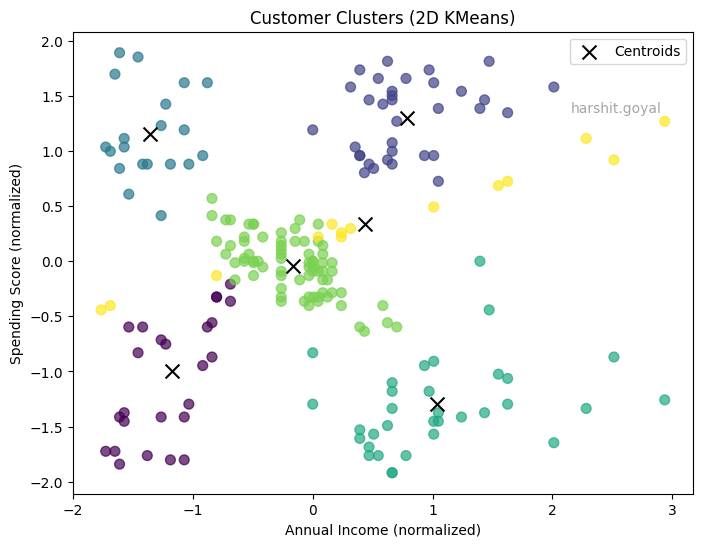

In [29]:
df = pd.read_csv('./Dataset/Q3/Clustering_dataset(in).csv')

customer_ids = df["CustomerID"]
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].mean())
df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].mean())
df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])

df['isMale'] = [1 if val == 'Male' else 0 for val in df['Genre']]
df.drop(columns=['Genre','CustomerID','isMale','Age'], inplace=True)

# df.info() # df.isnull().sum() # df.describe() # df.duplicated().sum()  # df.corr()
# df.head()

X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
X = (X - X.mean(axis=0)) / X.std(axis=0)

# apply GMM
gmm = GMM(n_clusters=6, max_iter=100000, tol=1e-4)
gmm.fit(X)
clusters = gmm.predict(X)
results = pd.DataFrame({
    "CustomerID": customer_ids,
    "Cluster": clusters
})

print("Means:\n", gmm.means)
# print("BIC:", gmm.bic(X))
print(results.head())
plt.figure(figsize=(8,6))
plt.scatter(
    X[:, 0], X[:, 1], 
    c=clusters,  s=50, alpha=0.7
)
plt.scatter(
    gmm.means[:, 0], gmm.means[:, 1], 
    c="black", marker="x", s=100, label="Centroids"
)
plt.text(
    0.95, 0.85, "harshit.goyal",
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.xlabel("Annual Income (normalized)")
plt.ylabel("Spending Score (normalized)")
plt.title("Customer Clusters (2D KMeans)")
plt.legend()
plt.show()

Fitted with best log-likelihood: -445.6984490840559
-445.69844374177745


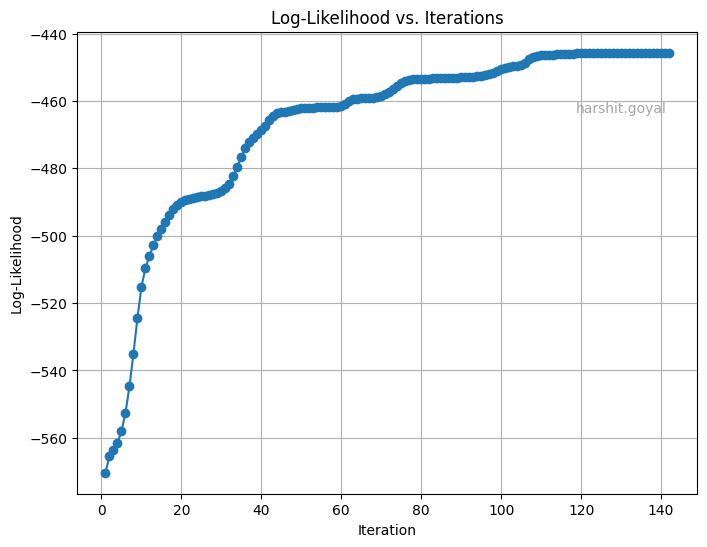

In [34]:
my_gmm = GMM(n_clusters=6, max_iter=10000, tol=1e-6)
my_gmm.fit(X, n_init=100)

print(my_gmm.getLikelihood(X))
my_gmm.drawLikelihood()

In [33]:
sk_gmm = GaussianMixture(n_components=6, max_iter=1000, tol=1e-6,init_params='random_from_data',n_init=10)
sk_gmm.fit(X) 

# sk_gmm.score_samples(X)
# compute total log-likelihood
total_log_likelihood = sk_gmm.score_samples(X).sum()
print(f'Scikit-learn GMM Log-Likelihood: {total_log_likelihood}')

Scikit-learn GMM Log-Likelihood: -444.09205927209473


## Determine the Optimal Number of Clusters

### BIC Bayesian Information Criterion

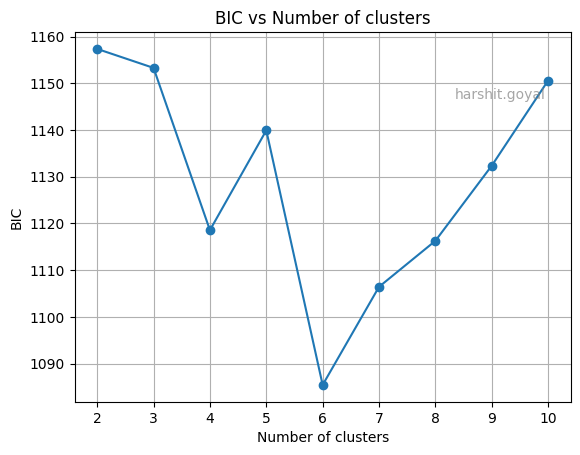

In [6]:
bics = []
for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X)
    bics.append(gmm.bic(X))

# Then plot bics vs k
plt.plot(range(2, 11), bics, marker='o')
plt.title('BIC vs Number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('BIC')
plt.grid(True)
plt.text(0.95, 0.85, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.show()


optimal value of k is the one that minimizes the BIC score.
Hence we will choose the value of k that corresponds to the lowest BIC score from the plot which is 6.

### Silhouette Method

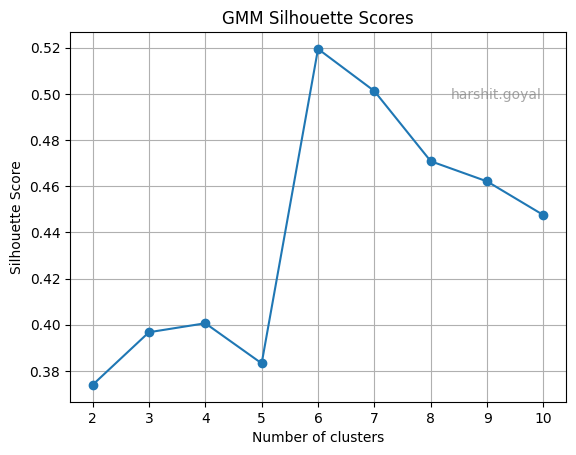

In [7]:
sil_scores = []
k_values = range(2, 11)  # silhouette undefined for k=1

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X)
    labels = gmm.predict(X)
    sil_scores.append(silhouette_score(X, labels))

# Plot
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('GMM Silhouette Scores')
plt.text(0.95, 0.85, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.grid(True)
plt.show()


optimal value of k is the one that maximizes the silhouette score.
Hence we will choose the value of k that corresponds to the highest silhouette score from the plot which is 6.